Loading data...


/var/folders/dt/pqrpvqxj6jnfx7sqqlbyy7_w0000gn/T/ipykernel_8094/1015985625.py:11: DtypeWarning: Columns (17,20) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_path)


Loaded 9512578 records

Data Overview:
Number of unique origin countries: 227
Number of unique destination countries: 227
Years in dataset: [2020]

1. CONTINENT ANALYSIS

Average Logistics Costs by Origin Continent:
                          mean       median           std    count
origin_continent                                                  
OC                15741.909497  3533.362691  25761.656106   472644
SA                 7388.952009  1464.523880  16075.274820   632092
AF                 6620.271927   677.169645  15120.306588  1621650
AS                 4855.056924   500.987897  12877.569233  2942150
EU                 4278.393479   418.582637  10992.021598  2648258

Average Logistics Costs by Origin-Destination Continent Pairs:
destination_continent            AF            AS            EU            OC  \
origin_continent                                                                
AF                      3351.267197   5726.559903   4447.238059  21188.803163   
AS      

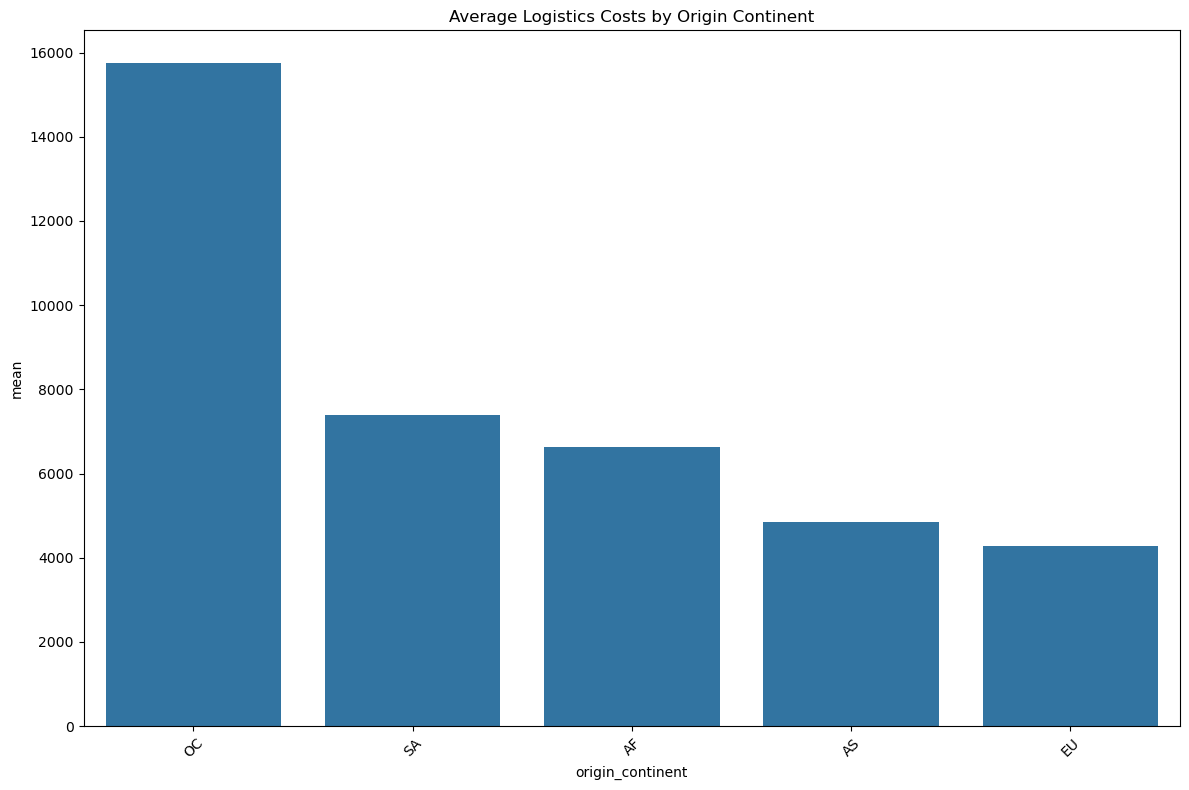

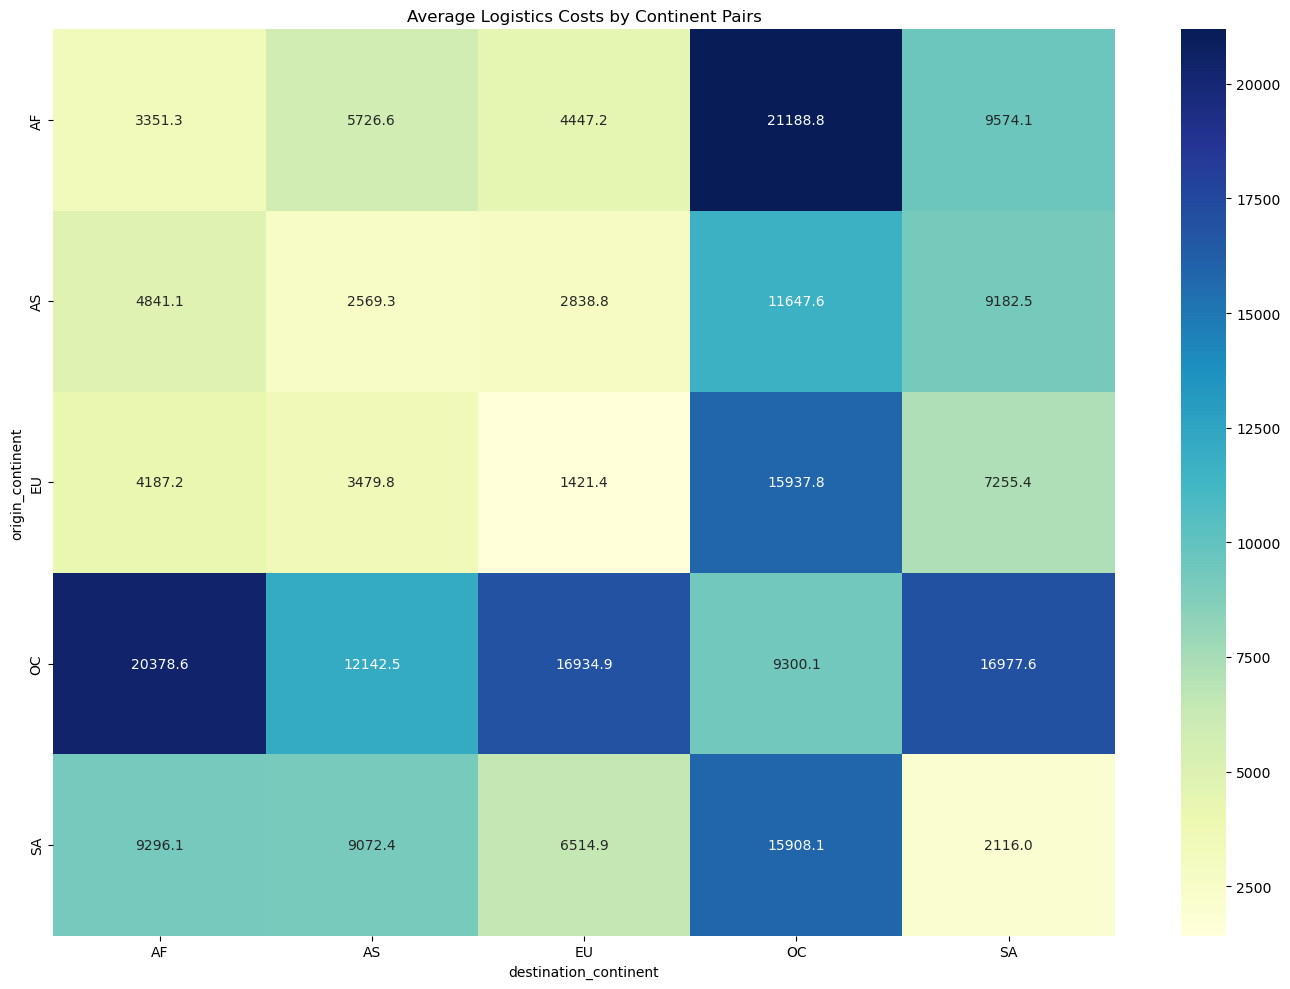

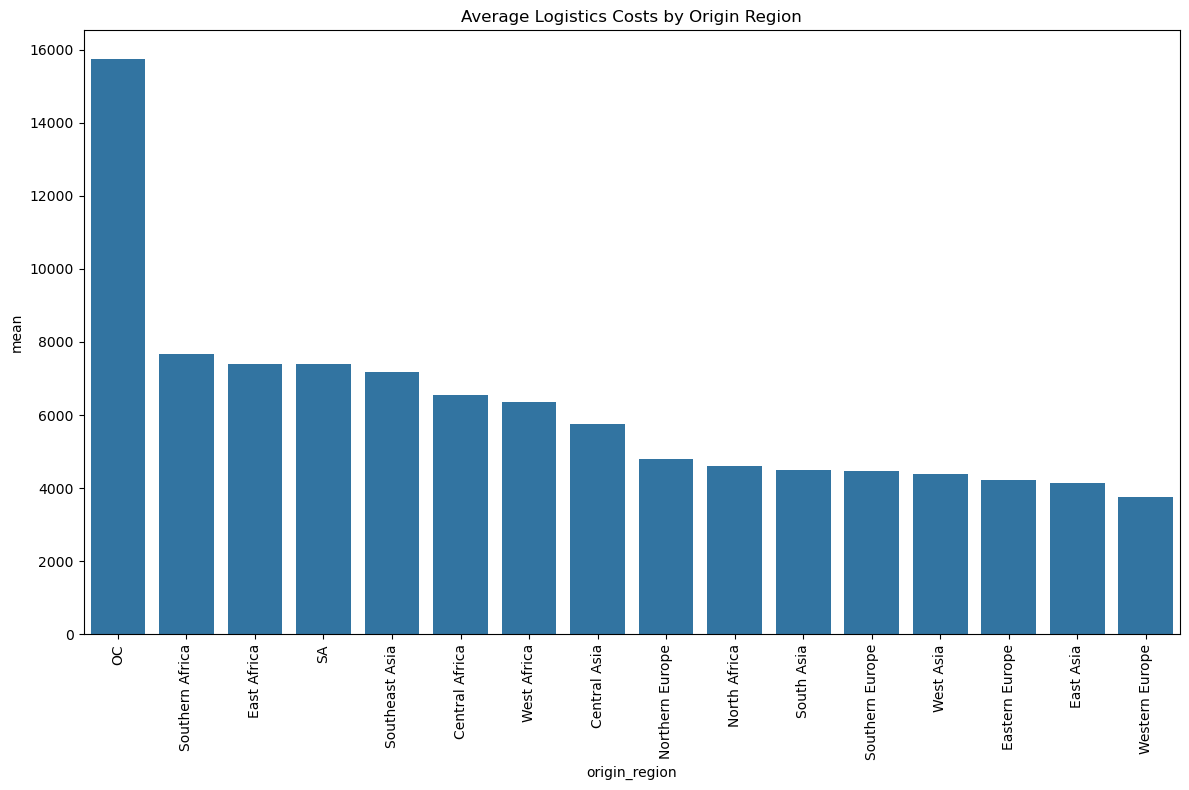

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set up paths
data_path = '../data/wb_data_all_fields_final.csv'

print("Loading data...")
df = pd.read_csv(data_path)
print(f"Loaded {len(df)} records")

# Basic info
print("\nData Overview:")
print(f"Number of unique origin countries: {df['origin_ISO'].nunique()}")
print(f"Number of unique destination countries: {df['destination_ISO'].nunique()}")
print(f"Years in dataset: {df['year'].unique()}")

# 1. Analysis by Continent
print("\n1. CONTINENT ANALYSIS")
print("===================")

# Calculate average costs by origin continent
continent_costs = df.groupby('origin_continent')['Unit logistics costs ($/ton)'].agg(['mean', 'median', 'std', 'count'])
continent_costs = continent_costs.sort_values('mean', ascending=False)

print("\nAverage Logistics Costs by Origin Continent:")
print(continent_costs)

# Continental flow analysis
continent_flow = pd.crosstab(df['origin_continent'], df['destination_continent'], 
                          values=df['Unit logistics costs ($/ton)'], aggfunc='mean')
print("\nAverage Logistics Costs by Origin-Destination Continent Pairs:")
print(continent_flow)

# 2. Analysis by Region
print("\n2. REGIONAL ANALYSIS")
print("==================")

# Calculate average costs by origin region
region_costs = df.groupby('origin_region')['Unit logistics costs ($/ton)'].agg(['mean', 'median', 'std', 'count'])
region_costs = region_costs.sort_values('mean', ascending=False)

print("\nAverage Logistics Costs by Origin Region:")
print(region_costs)

# Regional flow analysis
region_flow = pd.crosstab(df['origin_region'], df['destination_region'], 
                         values=df['Unit logistics costs ($/ton)'], aggfunc='mean')
print("\nAverage Logistics Costs by Origin-Destination Region Pairs:")
print(region_flow)

# 3. Analysis by Income Group
print("\n3. INCOME GROUP ANALYSIS")
print("======================")

# Check if there's a separate income group for origin and destination
if 'origin_income_group' in df.columns and 'destination_income_group' in df.columns:
    # Use separate income group columns
    income_origin = 'origin_income_group'
    income_dest = 'destination_income_group'
else:
    # Use the single income_group column
    # Assume this is for the origin country
    income_origin = 'income_group'
    income_dest = 'income_group'

# Calculate average costs by origin income group
income_costs = df.groupby(income_origin)['Unit logistics costs ($/ton)'].agg(['mean', 'median', 'std', 'count'])
income_costs = income_costs.sort_values('mean', ascending=False)

print(f"\nAverage Logistics Costs by Origin Income Group:")
print(income_costs)

# Income group flow analysis (if applicable)
if income_origin != income_dest:
    income_flow = pd.crosstab(df[income_origin], df[income_dest], 
                            values=df['Unit logistics costs ($/ton)'], aggfunc='mean')
    print("\nAverage Logistics Costs by Origin-Destination Income Group Pairs:")
    print(income_flow)

# Save results to CSV files
output_dir = '../output'
os.makedirs(output_dir, exist_ok=True)

# continent_costs.to_csv(f"{output_dir}/continent_costs.csv")
# continent_flow.to_csv(f"{output_dir}/continent_flow.csv")
# region_costs.to_csv(f"{output_dir}/region_costs.csv")
# region_flow.to_csv(f"{output_dir}/region_flow.csv")
# income_costs.to_csv(f"{output_dir}/income_costs.csv")
# if income_origin != income_dest:
#     income_flow.to_csv(f"{output_dir}/income_flow.csv")

# print("\nAnalysis complete. Results saved to CSV files in the output directory.")

# Optional: Create visualizations
try:
    plt.figure(figsize=(12, 8))
    sns.barplot(x=continent_costs.index, y=continent_costs['mean'])
    plt.title('Average Logistics Costs by Origin Continent')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(f"{output_dir}/continent_costs.png")
    
    plt.figure(figsize=(14, 10))
    sns.heatmap(continent_flow, annot=True, cmap='YlGnBu', fmt='.1f')
    plt.title('Average Logistics Costs by Continent Pairs')
    plt.tight_layout()
    plt.savefig(f"{output_dir}/continent_flow_heatmap.png")
    
    plt.figure(figsize=(12, 8))
    sns.barplot(x=region_costs.index, y=region_costs['mean'])
    plt.title('Average Logistics Costs by Origin Region')
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.savefig(f"{output_dir}/region_costs.png")
    
    print("Visualizations saved to output directory.")
except Exception as e:
    print(f"Error creating visualizations: {e}") 